# 02 — estimator 7종: 수식 → 코드 → 수치 walkthrough

> **지위 배너 — 재현/탐색 층.** 이 노트북이 새로 계산하는 수치는 전부 **LEDGER 미등재
> (정본 아님)** 이다. 정본 수치는 [`docs/LEDGER.md`](../docs/LEDGER.md) 뿐이며, 기존 결과를
> 인용할 때는 행 id 를 병기한다. 규약: [`notebooks/README.md`](README.md).
> **무대 라벨 — 본편 도구·백스테이지 채점.** estimator 계산은 로그만 필요하지만(§B·§C), 이 권의
> 채점(§A 참값·§D bias-variance)은 백스테이지다(GLOSSARY §8).

**한 로그 위에서 일곱 estimator 를 직접 계산한다 — 수식과 코드가 한 줄씩 대응.**

OPE estimator 는 결국 두 재료 — reward 모델 $\hat q(x,a)$ 와 importance weight
$w_i = \pi_e(a_i|x_i)/\pi_0(a_i|x_i)$ — 를 어떻게 섞느냐의 문제다. DM 은 모델만 쓰고(분산
최소·모델 bias 그대로), IPS 는 weight 만 쓰고(unbiased·분산 폭발 위험), 나머지 다섯은 그
사이 어딘가에서 weight 를 **길들인다**. 이 권은 `src/ope/estimators.py` 의 구현 7종을
수식 그대로 numpy 한 줄로 재계산해 일치를 확인하고(`assert np.isclose`), 같은 로그 위에서
추정치·오차·weight 변형·bias-variance 분해를 눈으로 본다. 정본 채점은 축 01–07
(`experiments/`, 백스테이지)의 몫이다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():  # notebooks/ 또는 repo 루트 어디서 실행해도 동작
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "experiments"))

from _style import (  # noqa: E402 — figure 팔레트·규율 공용 (estimator→색 entity 고정)
    ESTIMATOR_COLORS, ESTIMATOR_LABELS, ESTIMATOR_ORDER, ORACLE_COLOR, apply_style,
)

# _style 은 스크립트용으로 Agg 백엔드를 강제한다 — 노트북에서는 inline 렌더로 복원
%matplotlib inline
apply_style()
import matplotlib.pyplot as plt  # noqa: E402
from matplotlib.patches import Patch  # noqa: E402

GRAY = "#9a9a9a"

## A. 설정 — base config 로그 하나, 그리고 참값 (백스테이지 채점)

M2 base config(`experiments/_common.BASE_M2`, PLAN §2)의 로그 **하나**를 놓고 시작한다:
n=10,000 · K=10 · β_log=1(온건한 로깅) · β_eval=3(더 확신에 찬 평가 정책) · confounding 없음.
두 관례도 축 01–07 과 동일하게 가져온다:

- **q̂ = oracle shrink(α=0.9)**: $\hat q = 0.9\,q + 0.05$ — 참 함수를 안 채로 살짝 수축시킨
  "경미하지만 체계적인 오지정" (`experiments/01_sample_size.py` 관례).
- **hyperparameter 정책**: raw weight 분위에서 τ=p95(w), λ_clip=p90(w), λ_dros=p90(w)²
  (`experiments/_common.hyperparams_from_weights` — DRos 의 λ 는 w² 스케일).

참값 $V(\pi_e)$ 는 DGP 가 구조 seed 에서 200k MC 로 계산해 준다(`dgp.true_policy_value`) —
이 기준선 대비 오차를 끝까지 들고 간다.

In [2]:
from _common import BASE_M2, cached_v_true, evaluate_run, hyperparams_from_weights  # noqa: E402
from ope.dgp import make_synthetic_bandit_data  # noqa: E402

cfg = BASE_M2  # n=10_000, K=10, β_log=1.0, β_eval=3.0, seed=0
d = make_synthetic_bandit_data(cfg)
n, K = d.pi_e_dist.shape
idx = np.arange(n)

r, a, ps, pi_e = d.reward, d.action, d.pscore_logged, d.pi_e_dist
q_hat = 0.9 * d.q_true + 0.05           # oracle shrink α=0.9 — 축 01–07 관례
w = pi_e[idx, a] / ps                   # raw importance weight w_i = π_e(a_i|x_i)/π_0(a_i|x_i)
hp = hyperparams_from_weights(w)
v_true = cached_v_true(cfg)

print(f"log:  n={n:,}  K={K}  beta_log={cfg.beta_log}  beta_eval={cfg.beta_eval}  seed={cfg.seed}")
print(f"v_true = {v_true:.6f}")
print(f"raw w: mean={w.mean():.4f}  p90={np.quantile(w, 0.90):.3f}  max={w.max():.3f}")
print(f"hyperparams: tau(p95)={hp['tau']:.4f}  lam_clip(p90)={hp['lam_clip']:.4f}  "
      f"lam_dros(p90^2)={hp['lam_dros']:.4f}")

log:  n=10,000  K=10  beta_log=1.0  beta_eval=3.0  seed=0
v_true = 0.715392
raw w: mean=1.0045  p90=1.609  max=2.654
hyperparams: tau(p95)=1.7759  lam_clip(p90)=1.6086  lam_dros(p90^2)=2.5877


설정의 기하 두 장 — 왼쪽은 raw weight 분포(τ·λ 가 분포의 어디를 자르는지), 오른쪽은 q̂ 의
오지정 형태(identity 에서 살짝 수축된 직선). 일곱 estimator 는 전부 이 두 재료의 조합이다.

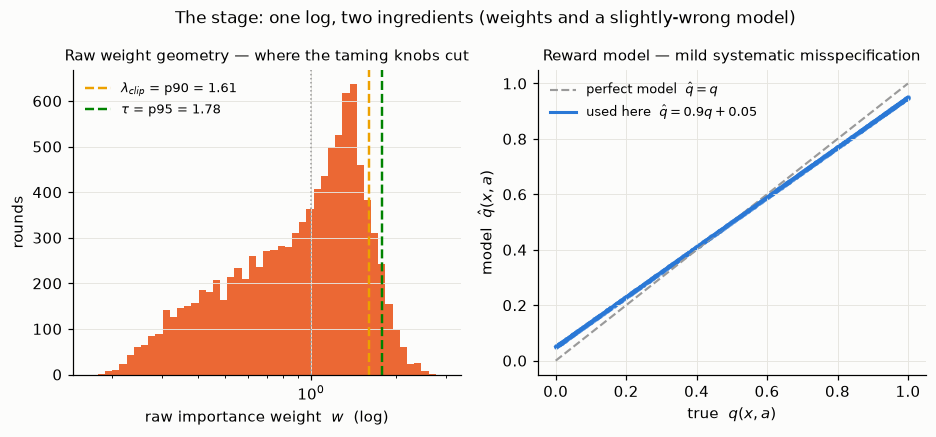

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

ax = axes[0]
bins = np.logspace(np.log10(w.min() * 0.9), np.log10(w.max() * 1.1), 50)
ax.hist(w, bins=bins, color=ESTIMATOR_COLORS["ips"])
ax.axvline(1.0, color=GRAY, lw=1, ls=":")
ax.axvline(hp["lam_clip"], color=ESTIMATOR_COLORS["clipped_ips"], lw=1.6, ls="--",
           label=f"$\\lambda_{{clip}}$ = p90 = {hp['lam_clip']:.2f}")
ax.axvline(hp["tau"], color=ESTIMATOR_COLORS["switch_dr"], lw=1.6, ls="--",
           label=f"$\\tau$ = p95 = {hp['tau']:.2f}")
ax.set_xscale("log")
ax.tick_params(axis="x", which="minor", labelbottom=False)  # 소수 눈금 라벨 겹침 방지
ax.set_xlabel("raw importance weight  $w$  (log)")
ax.set_ylabel("rounds")
ax.set_title("Raw weight geometry — where the taming knobs cut", fontsize=10)
ax.legend()

ax = axes[1]
qq = np.linspace(0.0, 1.0, 200)
ax.plot(qq, qq, color=GRAY, lw=1.4, ls="--", label="perfect model  $\\hat q = q$")
ax.plot(qq, 0.9 * qq + 0.05, color=ESTIMATOR_COLORS["dm"], lw=2.0,
        label="used here  $\\hat q = 0.9q + 0.05$")
sample = np.random.default_rng(0).choice(n * K, size=1500, replace=False)
ax.scatter(d.q_true.ravel()[sample], q_hat.ravel()[sample], s=4, alpha=0.25,
           color=ESTIMATOR_COLORS["dm"])
ax.set_xlabel("true  $q(x,a)$")
ax.set_ylabel("model  $\\hat q(x,a)$")
ax.set_title("Reward model — mild systematic misspecification", fontsize=10)
ax.legend()
fig.suptitle("The stage: one log, two ingredients (weights and a slightly-wrong model)",
             y=1.03, fontsize=11)
plt.show()

## B. 일곱 estimator — 수식 그대로 한 줄씩

각 소절의 구조는 같다: 수식 → 구현 호출(`estimate_*`) → **numpy 로 수식 그대로 1줄 재계산**
→ `assert np.isclose` 일치 확인. 공식 출처는 `estimators.py` docstring 과 동일
(DM/IPS/DR: Dudík–Langford–Li 2011 · SNIPS: Swaminathan–Joachims 2015 ·
Switch-DR: Wang–Agarwal–Dudík 2017 · DRos: Su+ 2020).

### B1. DM (Direct Method) — 로그를 안 믿고 모델을 믿는다

$$\hat V_{\mathrm{DM}} \;=\; \frac1n\sum_{i=1}^{n}\sum_{a=1}^{K}\pi_e(a|x_i)\,\hat q(x_i,a)$$

관측된 $(a_i, r_i)$ 를 아예 쓰지 않는다 — $\hat q$ 위에서 $\pi_e$ 로 적분할 뿐. 분산은
최소지만 bias 는 모델 오차가 그대로 전이된다(위 그림의 수축이 곧 bias).

In [4]:
from ope.estimators import estimate_dm  # noqa: E402

res_dm = estimate_dm(pi_e, q_hat)
manual = (pi_e * q_hat).sum(axis=1).mean()   # (1/n) Σ_i Σ_a π_e(a|x_i) q̂(x_i,a)
assert np.isclose(res_dm.value, manual, rtol=1e-12)
print(f"DM          = {res_dm.value:.10f}   manual = {manual:.10f}   MATCH")
print(f"error vs v_true = {res_dm.value - v_true:+.6f}")

DM          = 0.6946285965   manual = 0.6946285965   MATCH
error vs v_true = -0.020763


### B2. IPS (Inverse Propensity Scoring) — 로그만 믿고 다시 가중한다

$$w_i = \frac{\pi_e(a_i|x_i)}{\pi_0(a_i|x_i)},\qquad
\hat V_{\mathrm{IPS}} \;=\; \frac1n\sum_{i=1}^{n} w_i\, r_i$$

기록 propensity 가 맞다면 unbiased — 대신 분산이 $w$ 의 꼬리를 그대로 물려받는다.

In [5]:
from ope.estimators import estimate_ips  # noqa: E402

res_ips = estimate_ips(r, a, ps, pi_e)
manual = (w * r).mean()                      # (1/n) Σ_i w_i r_i
assert np.isclose(res_ips.value, manual, rtol=1e-12)
print(f"IPS         = {res_ips.value:.10f}   manual = {manual:.10f}   MATCH")
print(f"error vs v_true = {res_ips.value - v_true:+.6f}")

IPS         = 0.7210913303   manual = 0.7210913303   MATCH
error vs v_true = +0.005700


### B3. SNIPS (Self-Normalized IPS) — 합으로 나눠 스케일을 안정화

$$\hat V_{\mathrm{SNIPS}} \;=\; \frac{\sum_i w_i r_i}{\sum_i w_i}$$

분모 $\sum_i w_i$ 의 기대값은 $n$ 이지만 실현값은 로그마다 출렁인다 — 그 출렁임을 분자와
나눠 상쇄한다. 약간의 bias(소표본)와 큰 분산 절감의 교환. weight 자체는 변형하지 않는다.

In [6]:
from ope.estimators import estimate_snips  # noqa: E402

res_snips = estimate_snips(r, a, ps, pi_e)
manual = (w * r).sum() / w.sum()             # Σ_i w_i r_i / Σ_i w_i
assert np.isclose(res_snips.value, manual, rtol=1e-12)
print(f"SNIPS       = {res_snips.value:.10f}   manual = {manual:.10f}   MATCH")
print(f"error vs v_true = {res_snips.value - v_true:+.6f}")

SNIPS       = 0.7178541854   manual = 0.7178541854   MATCH
error vs v_true = +0.002462


### B4. Clipped-IPS — 꼬리를 λ 에서 자른다

$$\hat V_{\lambda} \;=\; \frac1n\sum_{i=1}^{n} \min(w_i,\lambda)\, r_i$$

$\lambda$ 는 bias–variance 다이얼: 자른 만큼 분산이 줄고, 자른 질량만큼 (하향) bias 가
생긴다. 여기서는 λ = p90(w) 관례를 쓴다.

In [7]:
from ope.estimators import estimate_clipped_ips  # noqa: E402

res_clip = estimate_clipped_ips(r, a, ps, pi_e, lam=hp["lam_clip"])
manual = (np.minimum(w, hp["lam_clip"]) * r).mean()   # (1/n) Σ_i min(w_i, λ) r_i
assert np.isclose(res_clip.value, manual, rtol=1e-12)
print(f"Clipped-IPS = {res_clip.value:.10f}   manual = {manual:.10f}   MATCH")
print(f"error vs v_true = {res_clip.value - v_true:+.6f}")

Clipped-IPS = 0.7016347090   manual = 0.7016347090   MATCH
error vs v_true = -0.013757


### B5. DR (Doubly Robust) — 모델을 baseline 으로, weight 는 잔차에만

$$\hat V_{\mathrm{DR}} \;=\; \frac1n\sum_{i=1}^{n}\Big[\underbrace{\textstyle\sum_a
\pi_e(a|x_i)\,\hat q(x_i,a)}_{\mathrm{DM}_i}
\;+\; w_i\big(r_i - \hat q(x_i,a_i)\big)\Big]$$

$\hat q$ 나 $\pi_0$ 둘 중 하나만 맞아도 consistent. weight 가 곱해지는 대상이 $r_i$ 가
아니라 **잔차** $r_i-\hat q_i$ 로 바뀌므로, 모델이 웬만하면 분산도 IPS 보다 작다.

In [8]:
from ope.estimators import estimate_dr  # noqa: E402

dm_terms = (pi_e * q_hat).sum(axis=1)        # DM_i = Σ_a π_e(a|x_i) q̂(x_i,a)
resid = r - q_hat[idx, a]                    # r_i − q̂(x_i, a_i)

res_dr = estimate_dr(r, a, ps, pi_e, q_hat)
manual = (dm_terms + w * resid).mean()       # (1/n) Σ_i [DM_i + w_i(r_i − q̂_i)]
assert np.isclose(res_dr.value, manual, rtol=1e-12)
print(f"DR          = {res_dr.value:.10f}   manual = {manual:.10f}   MATCH")
print(f"error vs v_true = {res_dr.value - v_true:+.6f}")

DR          = 0.7158417217   manual = 0.7158417217   MATCH
error vs v_true = +0.000450


### B6. Switch-DR — 위험한 weight 구간은 보정을 끄고 DM 에 맡긴다

$$\hat V_{\tau} \;=\; \frac1n\sum_{i=1}^{n}\Big[\mathrm{DM}_i
\;+\; w_i\,\mathbb 1[w_i \le \tau]\,\big(r_i - \hat q(x_i,a_i)\big)\Big]$$

clipping 이 weight 를 λ 로 **누르는** 것이라면, switch 는 τ 초과 구간에서 보정항을 아예
**꺼서** 그 표본을 DM 으로 처리한다 — 불연속(on/off) 다이얼.

In [9]:
from ope.estimators import estimate_switch_dr  # noqa: E402

res_sw = estimate_switch_dr(r, a, ps, pi_e, q_hat, tau=hp["tau"])
manual = (dm_terms + w * (w <= hp["tau"]) * resid).mean()  # (1/n) Σ_i [DM_i + w_i 1[w_i≤τ] resid_i]
assert np.isclose(res_sw.value, manual, rtol=1e-12)
print(f"Switch-DR   = {res_sw.value:.10f}   manual = {manual:.10f}   MATCH")
print(f"error vs v_true = {res_sw.value - v_true:+.6f}   "
      f"(switched-off share: {(w > hp['tau']).mean():.2%})")

Switch-DR   = 0.7119207959   manual = 0.7119207959   MATCH
error vs v_true = -0.003471   (switched-off share: 5.00%)


### B7. DRos (DR with Optimistic Shrinkage) — 자르지 말고 연속적으로 수축

$$\tilde w_i \;=\; \frac{\lambda\, w_i}{w_i^2+\lambda},\qquad
\hat V_{\lambda} \;=\; \frac1n\sum_{i=1}^{n}\big[\mathrm{DM}_i
+ \tilde w_i\,(r_i - \hat q(x_i,a_i))\big]$$

"clipping 의 원리화" — $\lambda\to 0^+$ 에서 DM, $\lambda\to\infty$ 에서 DR 로 연속적으로
이어지는 shrink 곡선이다. 큰 $w$ 일수록 강하게 수축되고($\tilde w \approx \lambda/w$),
작은 $w$ 는 거의 보존된다($\tilde w \approx w$).

In [10]:
from ope.estimators import estimate_dros  # noqa: E402

res_dros = estimate_dros(r, a, ps, pi_e, q_hat, lam=hp["lam_dros"])
manual = (dm_terms + (hp["lam_dros"] * w / (w**2 + hp["lam_dros"])) * resid).mean()
assert np.isclose(res_dros.value, manual, rtol=1e-12)
print(f"DRos        = {res_dros.value:.10f}   manual = {manual:.10f}   MATCH")
print(f"error vs v_true = {res_dros.value - v_true:+.6f}")

DRos        = 0.7046127177   manual = 0.7046127177   MATCH
error vs v_true = -0.010779


일곱 값을 한 화면에 — 왼쪽은 점추정과 참값 기준선, 오른쪽은 signed error. **한 로그**의
실현값이므로 우열 단정은 금물이다(그건 D 절과 축 01–07(백스테이지)의 몫) — 여기서 볼 것은 DM 의
체계적 하향(모델 수축의 전이)과 나머지 여섯이 참값 주위에 흩어지는 모양이다.

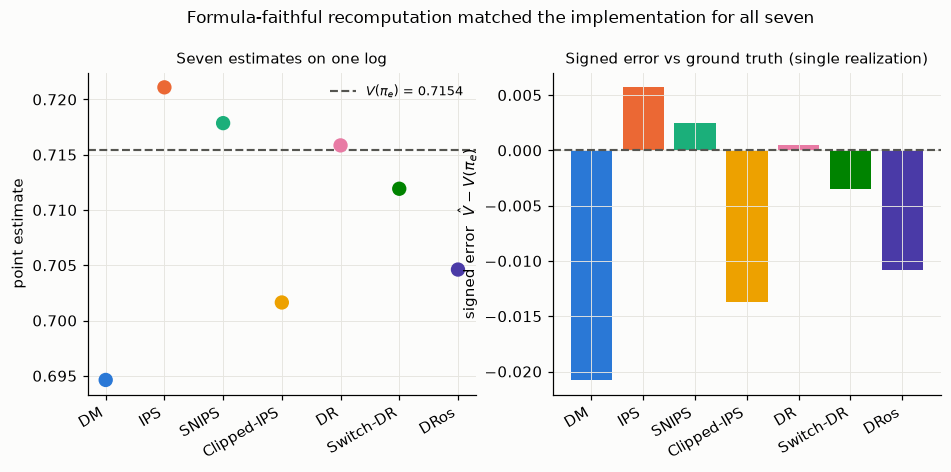

,estimate,signed_error,abs_error
DM,0.694629,-0.020763,0.020763
IPS,0.721091,+0.005700,0.005700
SNIPS,0.717854,+0.002462,0.002462
Clipped-IPS,0.701635,-0.013757,0.013757
DR,0.715842,+0.000450,0.000450
Switch-DR,0.711921,-0.003471,0.003471
DRos,0.704613,-0.010779,0.010779


In [11]:
values = {"dm": res_dm.value, "ips": res_ips.value, "snips": res_snips.value,
          "clipped_ips": res_clip.value, "dr": res_dr.value,
          "switch_dr": res_sw.value, "dros": res_dros.value}
ests = np.array([values[k] for k in ESTIMATOR_ORDER])
colors = [ESTIMATOR_COLORS[k] for k in ESTIMATOR_ORDER]
labels = [ESTIMATOR_LABELS[k] for k in ESTIMATOR_ORDER]
xs = np.arange(len(ESTIMATOR_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
ax = axes[0]
ax.axhline(v_true, color=ORACLE_COLOR, lw=1.4, ls="--", label=f"$V(\\pi_e)$ = {v_true:.4f}")
ax.scatter(xs, ests, s=70, color=colors, zorder=3)
ax.set_xticks(xs, labels, rotation=30, ha="right")
ax.set_ylabel("point estimate")
ax.set_title("Seven estimates on one log", fontsize=10)
ax.legend()

ax = axes[1]
ax.bar(xs, ests - v_true, color=colors)
ax.axhline(0.0, color=ORACLE_COLOR, lw=1.4, ls="--")
ax.set_xticks(xs, labels, rotation=30, ha="right")
ax.set_ylabel("signed error  $\\hat V - V(\\pi_e)$")
ax.set_title("Signed error vs ground truth (single realization)", fontsize=10)
fig.suptitle("Formula-faithful recomputation matched the implementation for all seven",
             y=1.03, fontsize=11)
plt.show()

display(pd.DataFrame({"estimate": ests, "signed_error": ests - v_true,
                      "abs_error": np.abs(ests - v_true)}, index=labels)
        .style.format("{:+.6f}", subset=["signed_error"])
        .format("{:.6f}", subset=["estimate", "abs_error"]))

## C. weight 변형의 시각화 — "estimator 차이 = weight 를 어떻게 길들이는가"

B 절의 수식을 다시 보면, IPS·Clipped·Switch·DRos 의 차이는 **weight 변환 함수 하나**로
요약된다: $w \mapsto w$ (그대로), $\min(w,\lambda)$ (누르기), $w\,\mathbb 1[w\le\tau]$
(끄기), $\lambda w/(w^2+\lambda)$ (수축). 왼쪽이 변환 규칙, 오른쪽이 이 로그에 실제 적용된
결과 분포다. SNIPS 는 개별 weight 를 건드리지 않고 전역 스케일만 바꾸므로 이 그림에 없다.

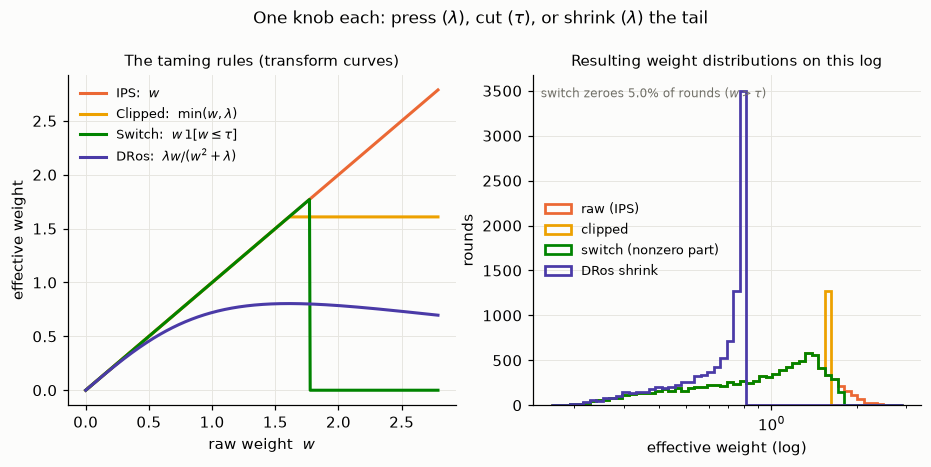

In [12]:
w_clip = np.minimum(w, hp["lam_clip"])
w_switch = w * (w <= hp["tau"])
w_dros = hp["lam_dros"] * w / (w**2 + hp["lam_dros"])
off_share = (w > hp["tau"]).mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
ax = axes[0]
wg = np.linspace(0.0, w.max() * 1.05, 500)
ax.plot(wg, wg, color=ESTIMATOR_COLORS["ips"], label="IPS:  $w$")
ax.plot(wg, np.minimum(wg, hp["lam_clip"]), color=ESTIMATOR_COLORS["clipped_ips"],
        label="Clipped:  $\\min(w,\\lambda)$")
ax.plot(wg, wg * (wg <= hp["tau"]), color=ESTIMATOR_COLORS["switch_dr"],
        label="Switch:  $w\\,1[w\\leq\\tau]$")
ax.plot(wg, hp["lam_dros"] * wg / (wg**2 + hp["lam_dros"]), color=ESTIMATOR_COLORS["dros"],
        label="DRos:  $\\lambda w/(w^2+\\lambda)$")
ax.set_xlabel("raw weight  $w$")
ax.set_ylabel("effective weight")
ax.set_title("The taming rules (transform curves)", fontsize=10)
ax.legend()

ax = axes[1]
pos = np.concatenate([w, w_clip, w_switch[w_switch > 0], w_dros])
bins = np.logspace(np.log10(pos.min() * 0.9), np.log10(pos.max() * 1.1), 55)
ax.hist(w, bins=bins, histtype="step", lw=1.8, color=ESTIMATOR_COLORS["ips"], label="raw (IPS)")
ax.hist(w_clip, bins=bins, histtype="step", lw=1.8, color=ESTIMATOR_COLORS["clipped_ips"],
        label="clipped")
ax.hist(w_switch[w_switch > 0], bins=bins, histtype="step", lw=1.8,
        color=ESTIMATOR_COLORS["switch_dr"], label="switch (nonzero part)")
ax.hist(w_dros, bins=bins, histtype="step", lw=1.8, color=ESTIMATOR_COLORS["dros"],
        label="DRos shrink")
ax.set_xscale("log")
ax.tick_params(axis="x", which="minor", labelbottom=False)  # 소수 눈금 라벨 겹침 방지
ax.set_xlabel("effective weight (log)")
ax.set_ylabel("rounds")
ax.set_title("Resulting weight distributions on this log", fontsize=10)
ax.annotate(f"switch zeroes {off_share:.1%} of rounds ($w>\\tau$)",
            xy=(0.02, 0.93), xycoords="axes fraction", fontsize=8, color="#6f6e66")
ax.legend()
fig.suptitle("One knob each: press ($\\lambda$), cut ($\\tau$), or shrink ($\\lambda$) the tail",
             y=1.03, fontsize=11)
plt.show()

clipped 분포는 λ 위치에 질량이 쌓이고(누른 흔적), switch 는 τ 초과 표본이 통째로 사라지며
(꺼진 흔적 — 그 몫은 DM 이 대신 짊어진다), DRos 는 꼬리가 $\lambda/w$ 로 되접혀 **큰 weight
일수록 더 강하게** 수축된다. 어느 다이얼이든 값을 얼마로 두느냐가 성적을 가른다 —
hyperparameter 민감도와 SLOPE 자동 선택의 정본 결과는 축 07(LEDGER `m2-07-slope`,
`results/tables/07_hyperparam_ieoe.csv`)이다.

## D. bias–variance 미니 아크 — 같은 일곱, 두 표본 크기

한 로그의 실현값은 운이다. S=30 seed 반복으로 $\mathrm{MSE} = \mathrm{bias}^2 +
\mathrm{var}$ 를 분해해 보자 — n∈{1,000, 10,000} 두 지점만 찍는 **탐색 지위** 미니 아크다
(정본 아크는 축 01–07(백스테이지): S=40–100, 5-지점 grid, `results/tables/01_*.csv` 등).
hyperparameter 는 로그별 적응(위 관례와 동일 — `evaluate_run` 기본 정책).

**정직 주의**: S=30 에서 불편 계열의 $\mathrm{bias}^2$ 추정치는 MC 노이즈 바닥
$\approx \mathrm{var}/S$ 을 가진다 — 그 바닥 근처의 막대 높이는 "bias 가 있다"로 읽으면 안 된다.

In [13]:
SEEDS = range(1000, 1030)  # S=30
recs = []
for n_i in (1_000, 10_000):
    cfg_n = cfg._replace(n=n_i)
    for seed in SEEDS:
        di = make_synthetic_bandit_data(cfg_n._replace(seed=seed))
        qh = 0.9 * di.q_true + 0.05
        recs += evaluate_run("nb02", "n", n_i, seed, di, qh, v_true)
arc = pd.DataFrame(recs)

dec = (arc.groupby(["knob_value", "estimator"])
          .apply(lambda g: pd.Series({
              "bias2": (g["estimate"] - g["v_true"]).mean() ** 2,
              "var": g["estimate"].var(ddof=1),
              "mse": ((g["estimate"] - g["v_true"]) ** 2).mean()}), include_groups=False)
          .reset_index())
display(dec.pivot(index="estimator", columns="knob_value", values=["bias2", "var", "mse"])
        .loc[ESTIMATOR_ORDER].style.format("{:.3e}"))

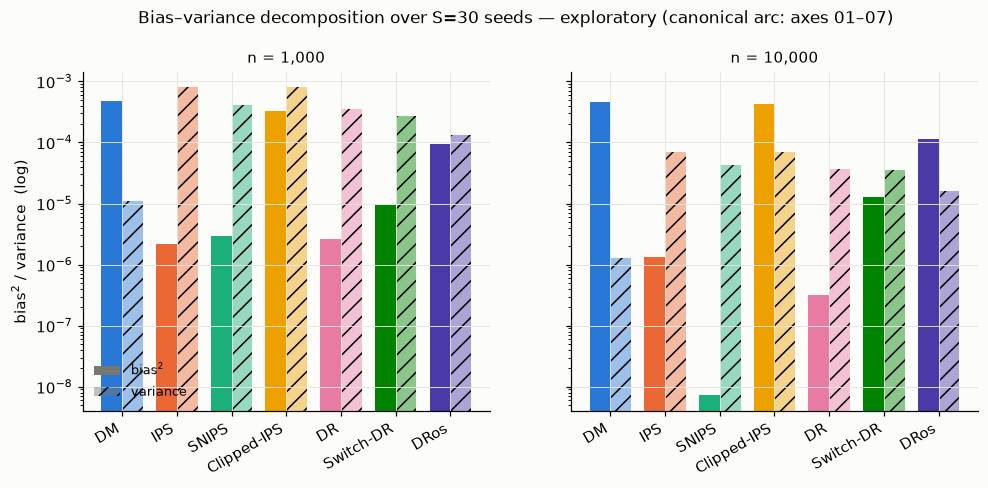

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
width = 0.38
for ax, n_i in zip(axes, (1_000, 10_000)):
    sub = dec[dec["knob_value"] == n_i].set_index("estimator").loc[ESTIMATOR_ORDER]
    ax.bar(xs - width / 2, sub["bias2"], width, color=colors)
    ax.bar(xs + width / 2, sub["var"], width, color=colors, alpha=0.45, hatch="//")
    ax.set_yscale("log")
    ax.set_xticks(xs, labels, rotation=30, ha="right")
    ax.set_title(f"n = {n_i:,}", fontsize=10)
axes[0].set_ylabel("bias$^2$ / variance  (log)")
axes[0].legend(handles=[Patch(facecolor="#777771", label="bias$^2$"),
                        Patch(facecolor="#777771", alpha=0.45, hatch="//", label="variance")],
               loc="lower left")
fig.suptitle(f"Bias–variance decomposition over S={len(SEEDS)} seeds — exploratory "
             "(canonical arc: axes 01–07)", y=1.02, fontsize=11)
plt.show()

읽는 법: DM 의 $\mathrm{bias}^2$ 는 n 을 키워도 그대로다(모델 오차는 표본과 무관) — 반면
weight 계열의 variance 는 대략 $1/n$ 으로 내려간다. 그래서 "작은 n 은 모델 쪽, 큰 n 은
weight 쪽"이라는 regime 교차가 생긴다(정본: 축 01 `results/tables/01_sample_size.csv`).
DR 계열은 잔차에만 weight 를 태워 양쪽 비용을 동시에 낮춘다.

## E. 교차검증 참조 — 이 구현은 외부 라이브러리와 산술 일치한다

이 노트북이 해부한 `src/ope/estimators.py` 구현 7종은 **obp 0.5.7(Python 3.9)** ·
**sb-obp(Python 3.12)** 두 트랙과 교차검증되어 전부 `match=True` (rel_tol=1e-8, 점추정만
게이트)다 — LEDGER `m1-crossval`, committed `results/tables/m1_obp_crossval.csv`.
아래는 그 committed 파일의 **인용**(재실행 아님 — 교차검증 재실행은 별도 pinned env
`.venv-obp`/`.venv-sbobp` 소관, `experiments/m1_crossval/`).

In [15]:
crossval = pd.read_csv(ROOT / "results" / "tables" / "m1_obp_crossval.csv", comment="#")
display(crossval.style.format({"mine": "{:.12f}", "obp_py39": "{:.12f}", "sbobp_py312": "{:.12f}"})
        .hide(axis="index"))

estimator,mine,obp_py39,rel_diff_obp_py39,match_obp_py39,sbobp_py312,rel_diff_sbobp_py312,match_sbobp_py312
dm,0.607785123661,0.607785123661,0.000000,True,0.607785123661,0.000000,True
ips,0.712253723926,0.712253723926,0.000000,True,0.712253723926,0.000000,True
snips,0.714149461990,0.714149461990,0.000000,True,0.714149461990,0.000000,True
clipped_ips,0.692657324007,0.692657324007,0.000000,True,0.692657324007,0.000000,True
dr,0.714619562521,0.714619562521,0.000000,True,0.714619562521,0.000000,True
switch_dr,0.695628369758,0.695628369758,0.000000,True,0.695628369758,0.000000,True
dros,0.678645034690,0.678645034690,0.000000,True,0.678645034690,0.000000,True


## F. 정리 — "어느 것을 쓰나"는 로그 기하에 달렸다

일곱 estimator 는 한 스펙트럼 위에 있다: 모델을 믿는 극단(DM)과 로그를 믿는 극단(IPS)
사이에서, weight 를 **누르고(λ)·끄고(τ)·수축시키는(DRos λ)** 방식이 다를 뿐이다. 오늘의
한 로그에서 누가 이겼는지는 대답이 아니다 — 대답은 로그의 기하(n·overlap·q̂ 품질)가
어느 regime 에 있느냐다.

- **백스테이지 증거층 지도**(M8 이후 README 3막 — hero 아님): hero regime map — 28-cell 승자
  지도에서 dr 9 · switch_dr 8 · dros 11 cells, DM·IPS 계열 outright 0, tie 21/28
  (LEDGER `m3-hero-map`, `results/tables/hero_regime_map.csv`).
- **방법론 산문**: [`docs/PLAYBOOK.md`](../docs/PLAYBOOK.md) — estimator 선택과 게이트
  판정의 운영 규칙.
- **다음 권(03)**: 추정치를 "언제 믿으면 안 되는가" — ESS·max-weight 진단과 decision gate
  의 계산 과정을 해부한다. 그리고 GT-미상 프로토콜(validity battery)은 05권이다.